# TITLE: Bike Demand Prediction: An End-to-End Machine Learning Project

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

## Source = Kaggle (https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset?utm_source=chatgpt.com)

- #### instant: record index
- #### dteday : date
- #### season : season (1:springer, 2:summer, 3:fall, 4:winter)
- #### yr : year (0: 2011, 1:2012)
- #### mnth : month ( 1 to 12)
- #### hr : hour (0 to 23)
- #### holiday : weather day is holiday or not (extracted from [Web Link])
- #### weekday : day of the week
- #### workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
- #### weathersit :
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- #### temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- #### atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- #### hum: Normalized humidity. The values are divided to 100 (max)
- #### windspeed: Normalized wind speed. The values are divided to 67 (max)
- #### casual: count of casual users
- #### registered: count of registered users
- #### cnt: count of total rental bikes including both casual and registered

## Problem Statement

- Bike-sharing systems generate large volumes of data reflecting rental patterns. 
These patterns are influenced by various factors such as weather conditions, temperature, seasonality, and time-related variables.Understanding these factors is essential to accurately predict bike demand and improve operational efficiency.

## Objective

The objective of this project is to:

- Analyze the factors affecting bike rental demand
- Identify key variables influencing usage patterns
- Build a machine learning model to predict total bike rentals (cnt)

This project focuses on developing an end-to-end machine learning pipeline, covering data analysis, model building, and deployment.

A baseline model (Linear Regression) is used for simplicity and interpretability, while advanced models and tuning are considered as future improvements.

## Business Use Case

This model can help businesses to:

- Optimize bike availability across different locations
- Improve customer satisfaction by reducing shortages
- Enhance operational efficiency through better resource planning
- Support data-driven decision-making

# Step 1: Load Dataset & Understand The data

In [3]:
df = pd.read_csv('../data/raw/day.csv')

In [4]:
# Glimpse first five row
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
# Glimpse last five row
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [6]:
# Shape
df.shape

(731, 16)

In [7]:
print("Number of Rows: ", df.shape[0])
print("Number of Columns: ", df.shape[1])

Number of Rows:  731
Number of Columns:  16


In [8]:
# Size
print("The size of DataFrame: ", df.size)

The size of DataFrame:  11696


In [9]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


- Dataset contains 731 rows and 16 columns
- No missing values found.
- Data types are appropriate for analysis.
- cnt is Target variable, This is regression problem.

In [10]:
# Describe The data
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


# Step 2:  Data Cleaning

## 1. Check null values

In [11]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Observations:

- No null values.

## 2. Check Duplicates

In [12]:
dups = df.duplicated().sum()
dups

np.int64(0)

#### Observations:

- No duplicate rows.

## 3. Check Bad values

In [13]:
# 3.1 Check Unique Values (Categorical Columns)

In [14]:
print(df['season'].unique())
print(df['yr'].unique())
print(df['mnth'].unique())
print(df['holiday'].unique())
print(df['weekday'].unique())
print(df['workingday'].unique())
print(df['weathersit'].unique())

[1 2 3 4]
[0 1]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[0 1]
[6 0 1 2 3 4 5]
[0 1]
[2 1 3]


#### Observations:

- All the columns have expected categories.

In [15]:
# 3.2 Check Value Ranges (Numerical Columns)

In [16]:
df[['temp','atemp','hum','windspeed','casual','registered','cnt']].describe()

,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Observations:
- No negative values in any columns.
- No extremely high/low values

In [17]:
# 3.3 Logical Checks

In [18]:
(df['casual'] + df['registered'] != df['cnt']).sum()

np.int64(0)

- No data inconsistency.

In [19]:
# 3.4. Outlier Detection

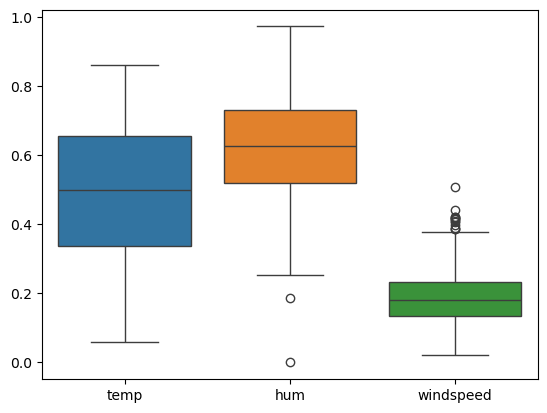

In [20]:
import seaborn as sns
sns.boxplot(data=df[['temp','hum','windspeed']])
plt.show()

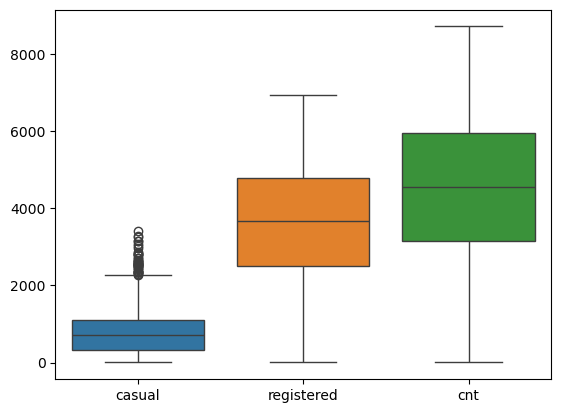

In [21]:
import seaborn as sns
sns.boxplot(data=df[['casual','registered','cnt']])
plt.show()

#### Insights:

- Humidty have negative outliers. In real life, humidity = 0 is almost impossible.
- windspeed have postive outliers. But this is expected values and do not need treatment.
- casual have postive outliers. But this is expected values and do not need treatment.
- Other categorical features like temp and cnt do not have any outliers.

# Target Variable Analysis

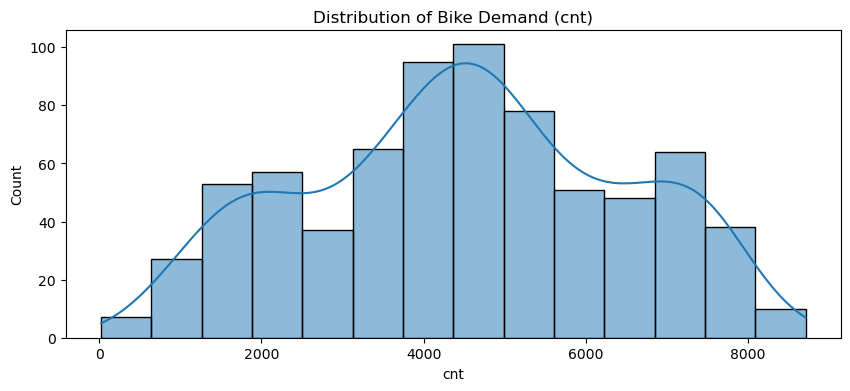

In [22]:
plt.figure(figsize = (10,4))
sns.histplot(df['cnt'], kde = True)
plt.title("Distribution of Bike Demand (cnt)")
plt.show()

#### Observations:
- Looks bell-shaped
- No heavy tail
- Smooth curve
- This means the cnt data is approximately normally distributed.

In [23]:
print("Mean: ",df['cnt'].mean())
print("Median", df['cnt'].median())
print("Skewness", df['cnt'].skew())

Mean:  4504.3488372093025
Median 4548.0
Skewness -0.04735278011900183


# Step 4: EDA (Exploratory Data Analysis)

### 1. Univariate Analysis

##### Distribution and spread for continuous attribute, distribution of data in categories for categorical ones

In [24]:
# Histogram

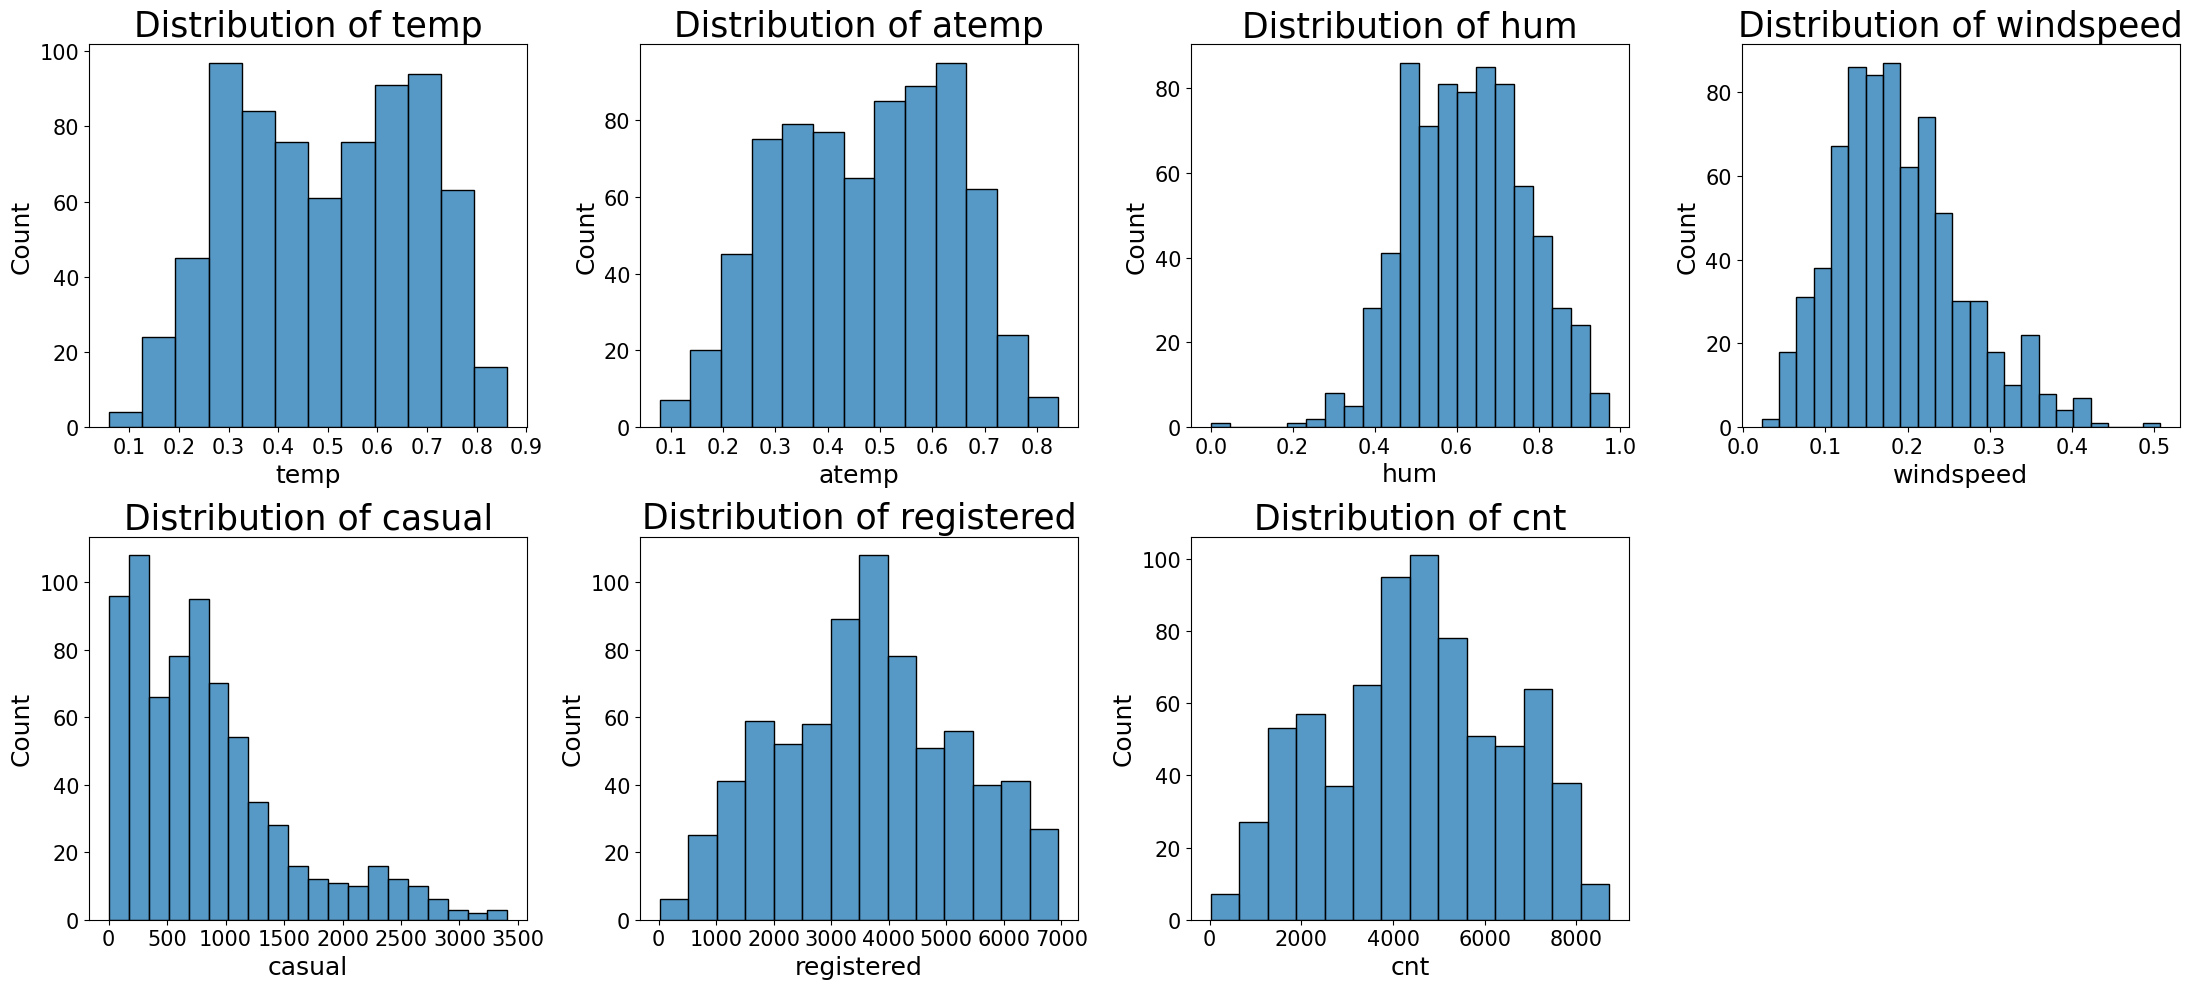

In [25]:
plt.figure(figsize = (22,10))

plt.subplot(2,4,1)
sns.histplot(data = df, x = 'temp')
plt.title("Distribution of temp", fontsize=(25))
plt.xlabel("temp", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,2)
sns.histplot(data = df, x = 'atemp')
plt.title("Distribution of atemp",fontsize=(25))
plt.xlabel("atemp", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,3)
sns.histplot(data = df, x = 'hum')
plt.title("Distribution of hum",fontsize=(25))
plt.xlabel("hum", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,4)
sns.histplot(data = df, x = 'windspeed')
plt.title("Distribution of windspeed",fontsize=(25))
plt.xlabel("windspeed", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,5)
sns.histplot(data = df, x = 'casual')
plt.title("Distribution of casual",fontsize=(25))
plt.xlabel("casual", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,6)
sns.histplot(data = df, x = 'registered')
plt.title("Distribution of registered",fontsize=(25))
plt.xlabel("registered", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,7)
sns.histplot(data = df, x = 'cnt')
plt.title("Distribution of cnt",fontsize=(25))
plt.xlabel("cnt", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.tight_layout()
plt.show()

#### Insights:

- Numerical features (temp, atemp, hum, windspeed, registred) are well distributed except for casual which appear to be slight right skewed. This may be due to postive outliers.

In [26]:
# Boxplot

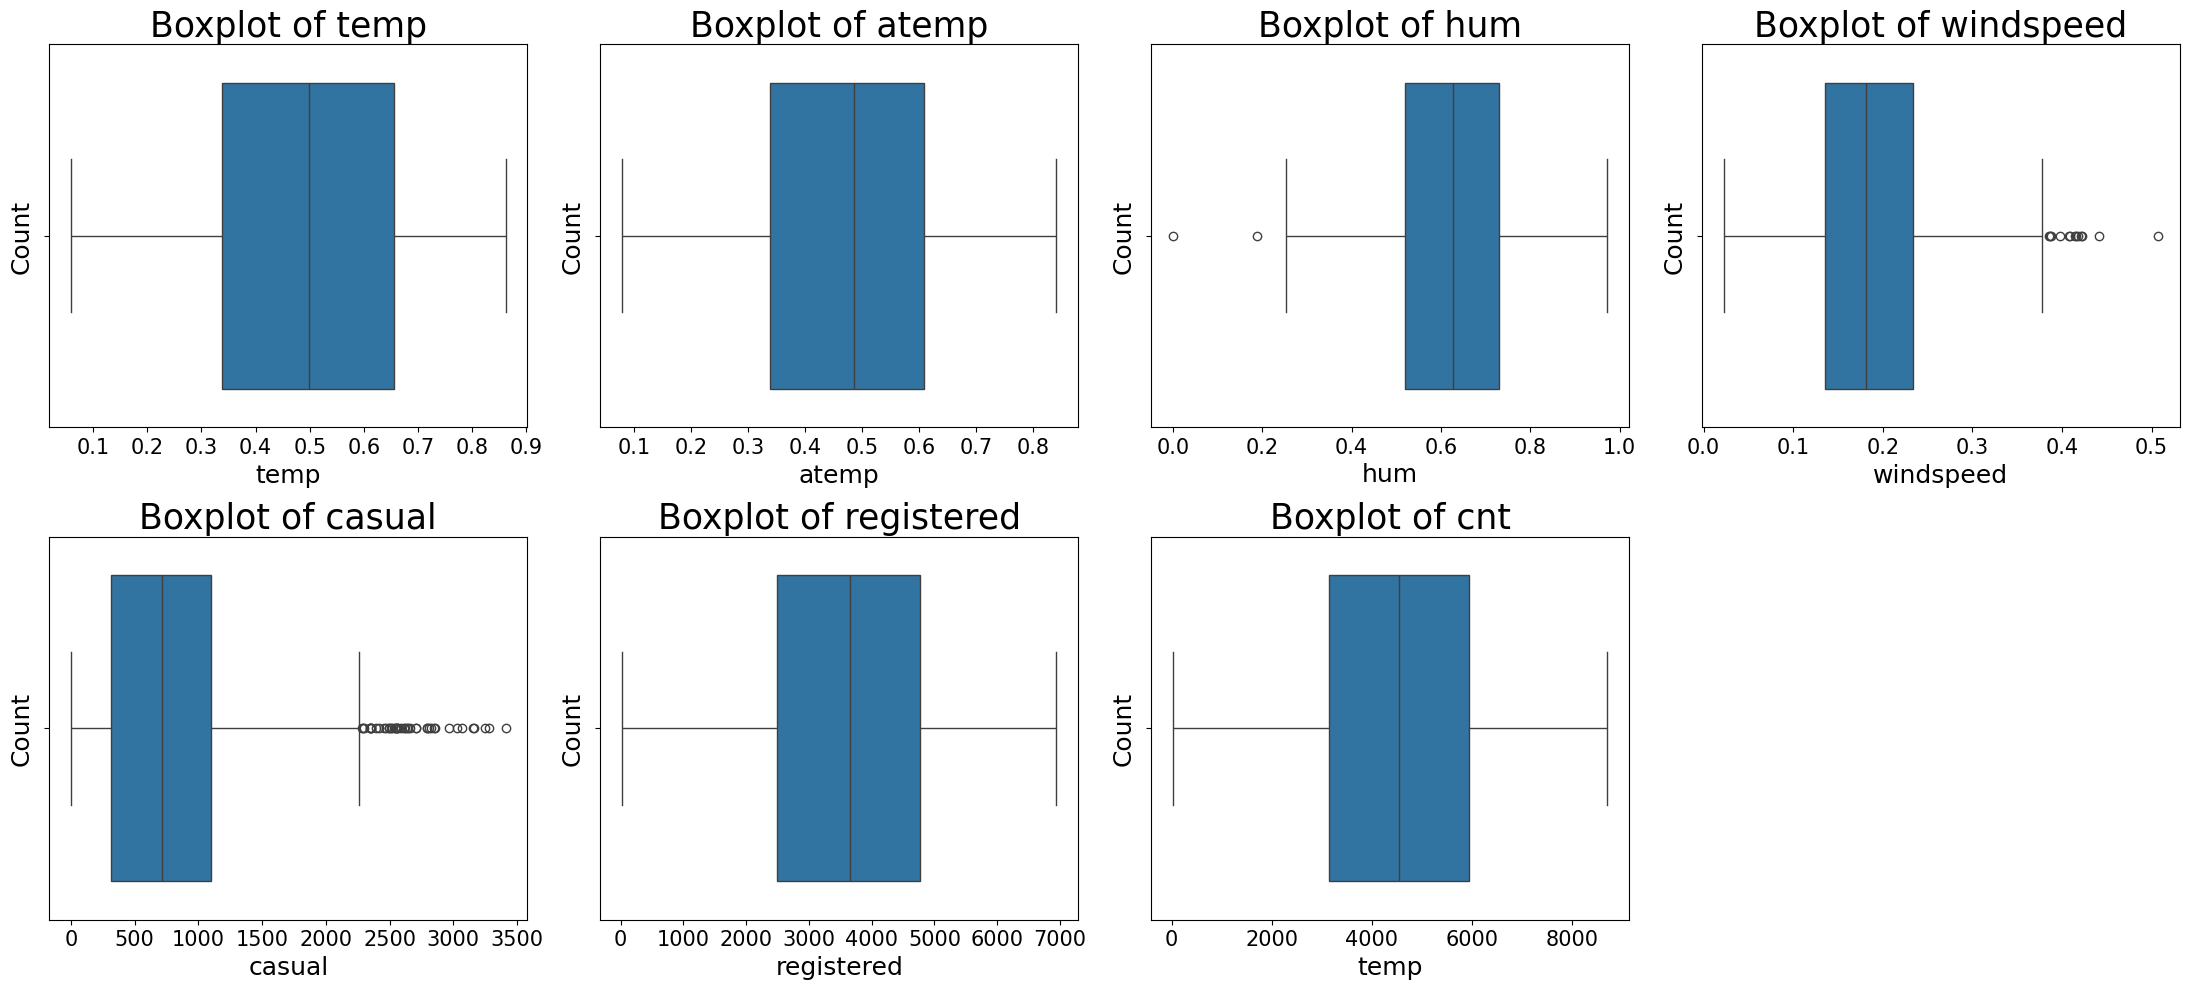

In [27]:
plt.figure(figsize = (22,10))

plt.subplot(2,4,1)
sns.boxplot(data = df, x = 'temp')
plt.title("Boxplot of temp", fontsize=(25))
plt.xlabel("temp", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,2)
sns.boxplot(data = df, x = 'atemp')
plt.title("Boxplot of atemp",fontsize=(25))
plt.xlabel("atemp", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,3)
sns.boxplot(data = df, x = 'hum')
plt.title("Boxplot of hum",fontsize=(25))
plt.xlabel("hum", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,4)
sns.boxplot(data= df, x = 'windspeed')
plt.title("Boxplot of windspeed",fontsize=(25))
plt.xlabel("windspeed", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,5)
sns.boxplot(data = df, x = 'casual')
plt.title("Boxplot of casual",fontsize=(25))
plt.xlabel("casual", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,6)
sns.boxplot(data = df, x = 'registered')
plt.title("Boxplot of registered",fontsize=(25))
plt.xlabel("registered", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,7)
sns.boxplot(data = df, x = 'cnt')
plt.title("Boxplot of cnt",fontsize=(25))
plt.xlabel("temp", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.tight_layout()
plt.show()

- Exept for hum, windspeed and casual all the other features do not have outliers.
- Since hum and windspeed are normalized feature they do not need outliers treatment.
- Casual do not have extreme outliers and also do not need treatment for outliers.

In [28]:
# Countplot(Categorical)

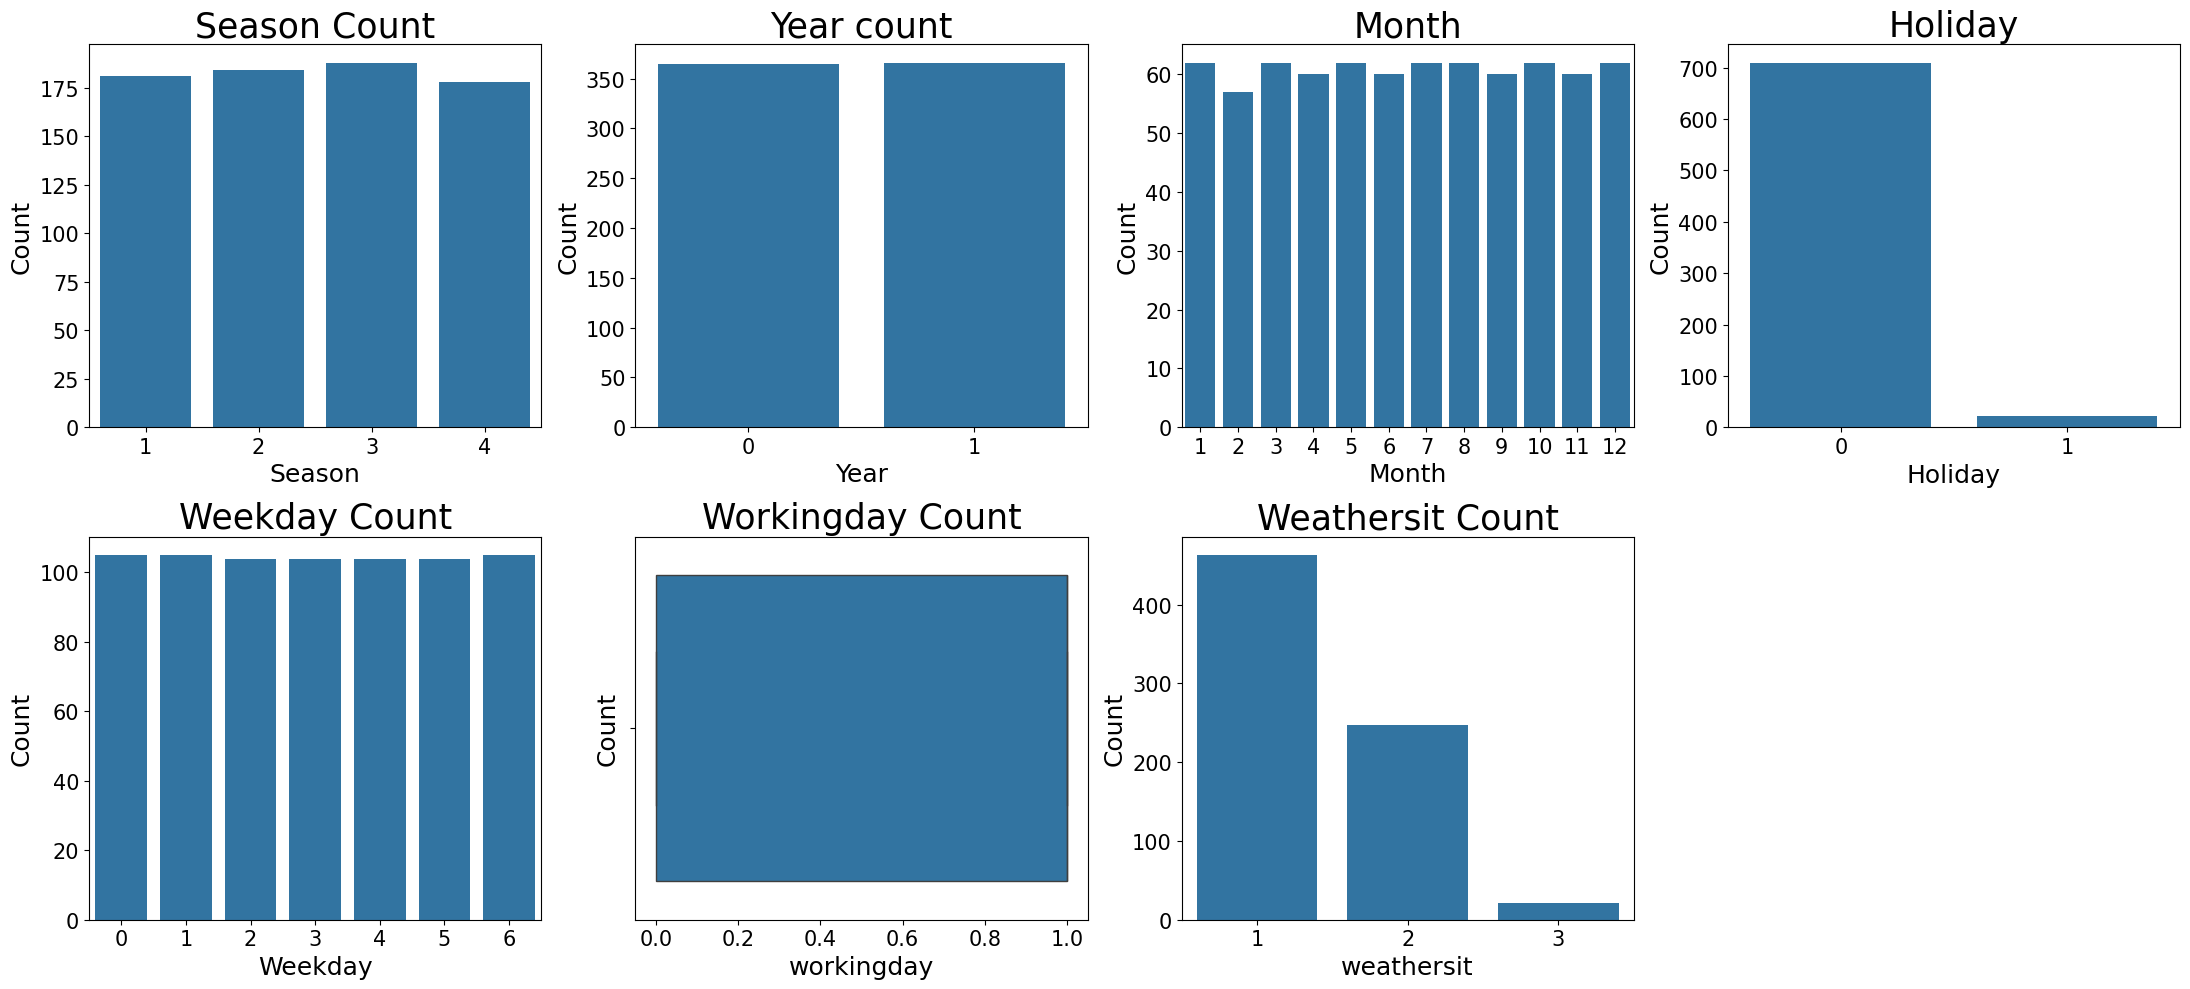

In [29]:
plt.figure(figsize = (22,10))

plt.subplot(2,4,1)
sns.countplot(data = df, x = 'season')
plt.title("Season Count", fontsize=(25))
plt.xlabel("Season", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,2)
sns.countplot(data = df, x = 'yr')
plt.title("Year count",fontsize=(25))
plt.xlabel("Year", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,3)
sns.countplot(data = df, x = 'mnth')
plt.title("Month",fontsize=(25))
plt.xlabel("Month", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,4)
sns.countplot(data = df, x = 'holiday')
plt.title("Holiday",fontsize=(25))
plt.xlabel("Holiday", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,5)
sns.countplot(data = df, x = 'weekday')
plt.title("Weekday Count",fontsize=(25))
plt.xlabel("Weekday", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,6)
sns.boxplot(data = df, x = 'workingday')
plt.title("Workingday Count",fontsize=(25))
plt.xlabel("workingday", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.subplot(2,4,7)
sns.countplot(data = df, x = 'weathersit')
plt.title("Weathersit Count",fontsize=(25))
plt.xlabel("weathersit", fontsize=(18))
plt.ylabel("Count", fontsize=(18))
plt.xticks(fontsize=(15))
plt.yticks(fontsize=(15))

plt.tight_layout()
plt.show()

#### Observations:
- All 4 seasons have almost equal counts. No bias toward any season
- Year 0 and 1 are almost equal. 
- All 12 months have uniform distribution.
- Holiday = 1 has very few observations and Holiday = 0 dominates and have counts more than 700. Dataset is highly imbalanced for holidays.
- All weekdays (0–6) are evenly distributed.
- Mostly working days (1) and Few non-working days (0)
- Weather 1(clear) ---> highest, Weather 2 ---> moderate and Weather 3 ---> very low

## 2. Bivariate Analysis

In [30]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [31]:
### Numerical Vs Numerical (Pairplot)

In [32]:
df_num = df.drop(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday' , 'weathersit'], axis =1)

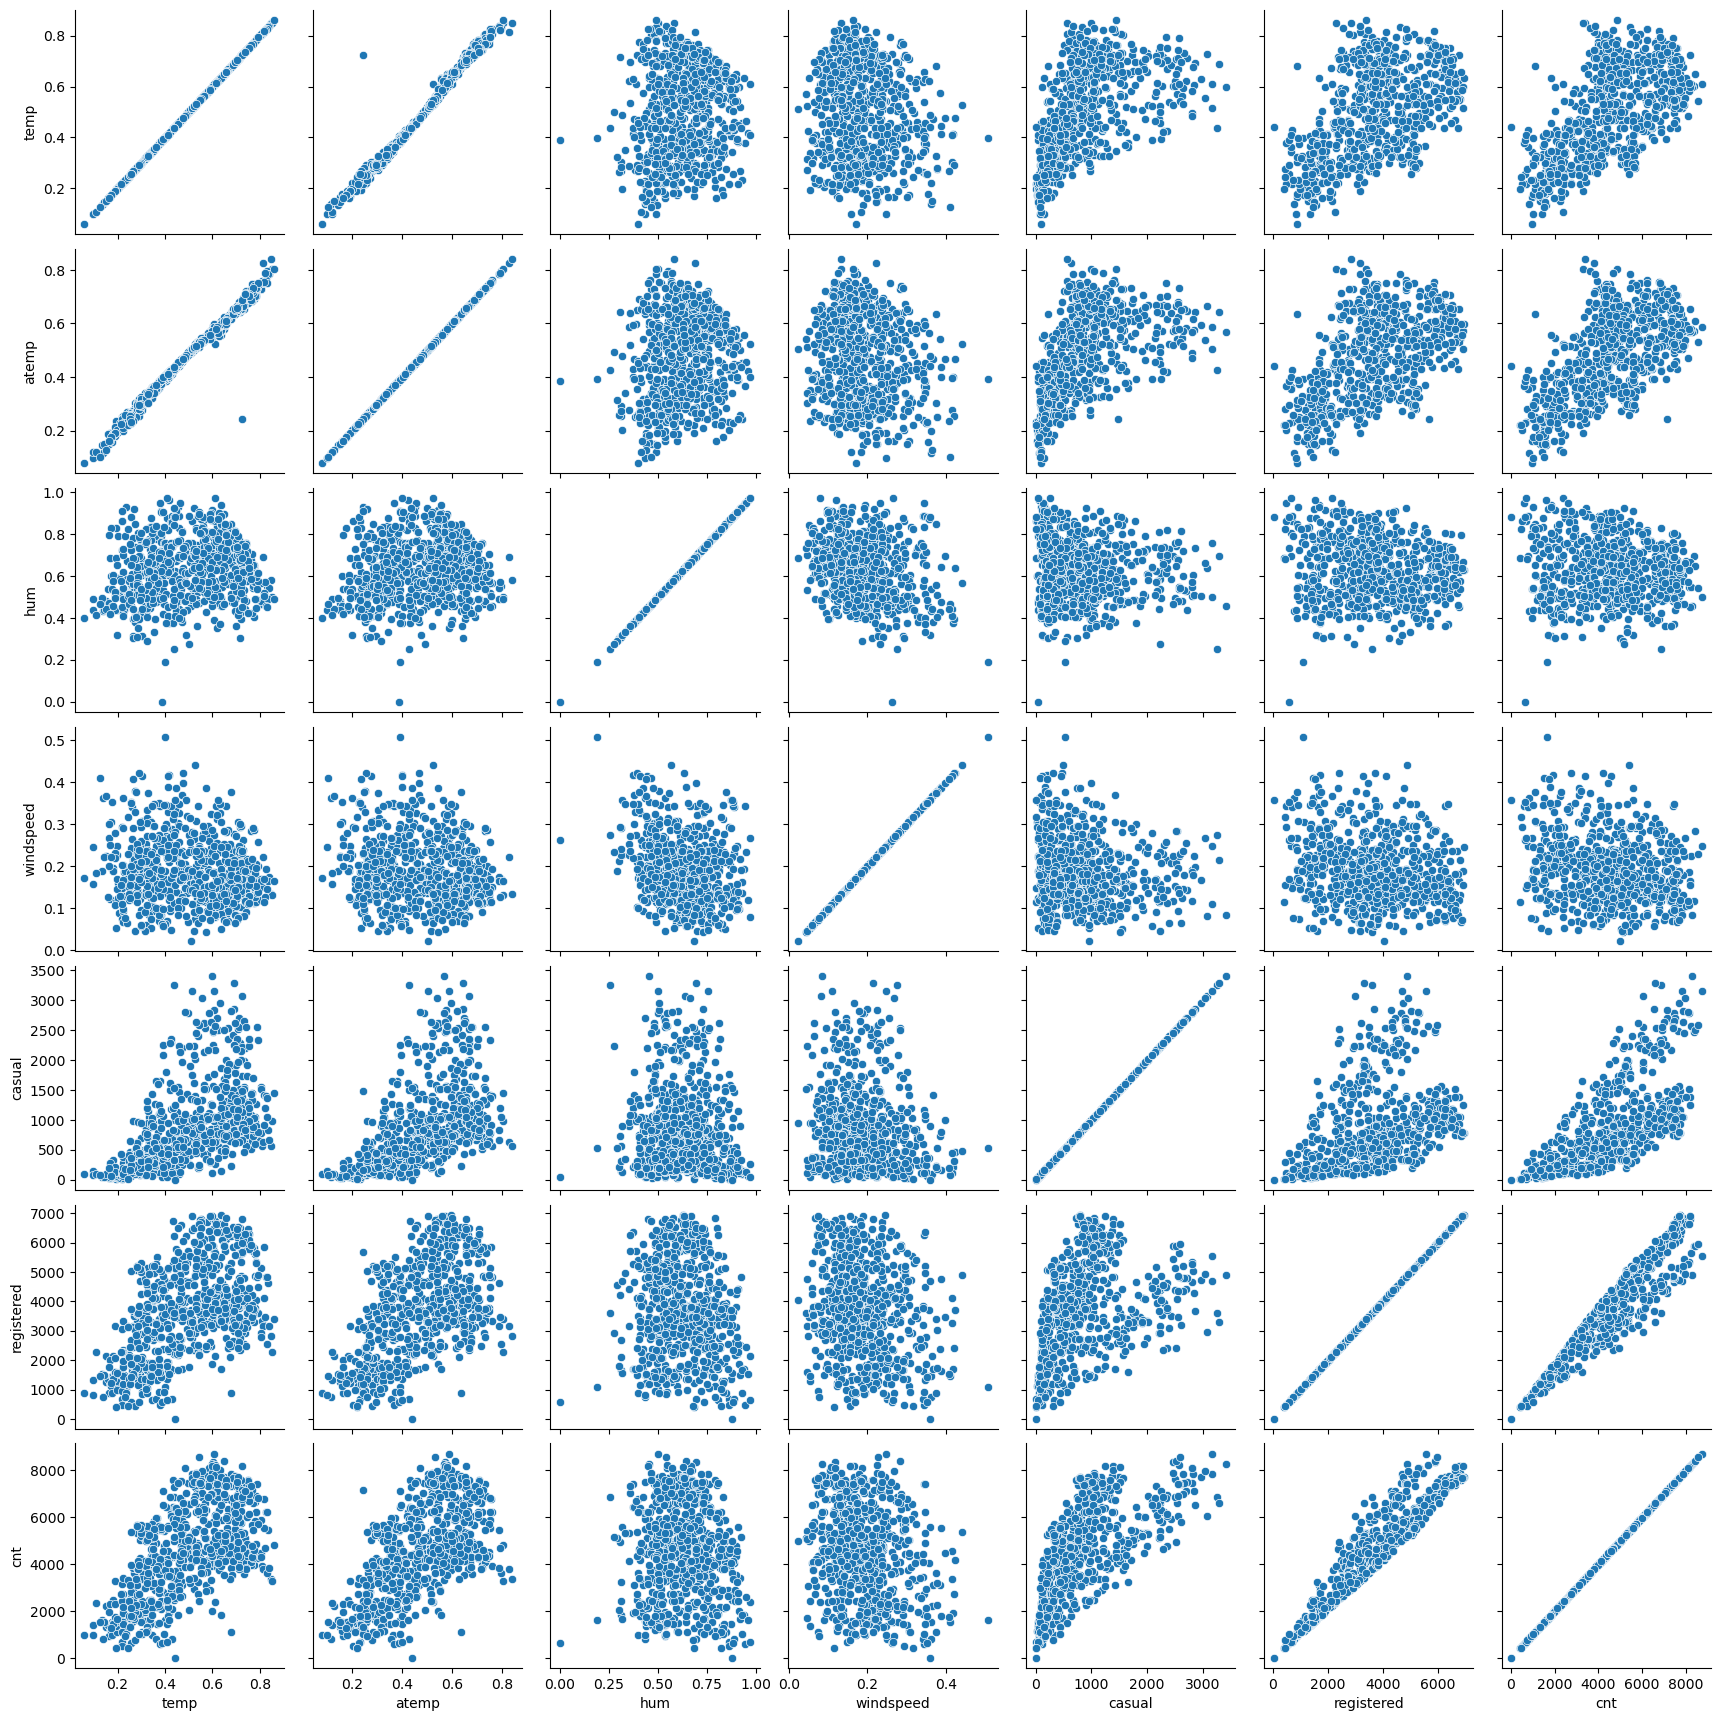

In [33]:
sns.pairplot(df_num , diag_kind=None)
plt.show()

#### Insights:

- There is strong linear relationship between target (cnt) and registered.
- There is also linear relationship between cnt and temp, atemp and casual, however the relationship is not so strong as between target (cnt) and registered.
- Some independent features also show some form of weak linear relationship between themself like (temp and atemp) and (causal and registered).

#### Category vs Numerical

In [34]:
# Season vs # Total Count

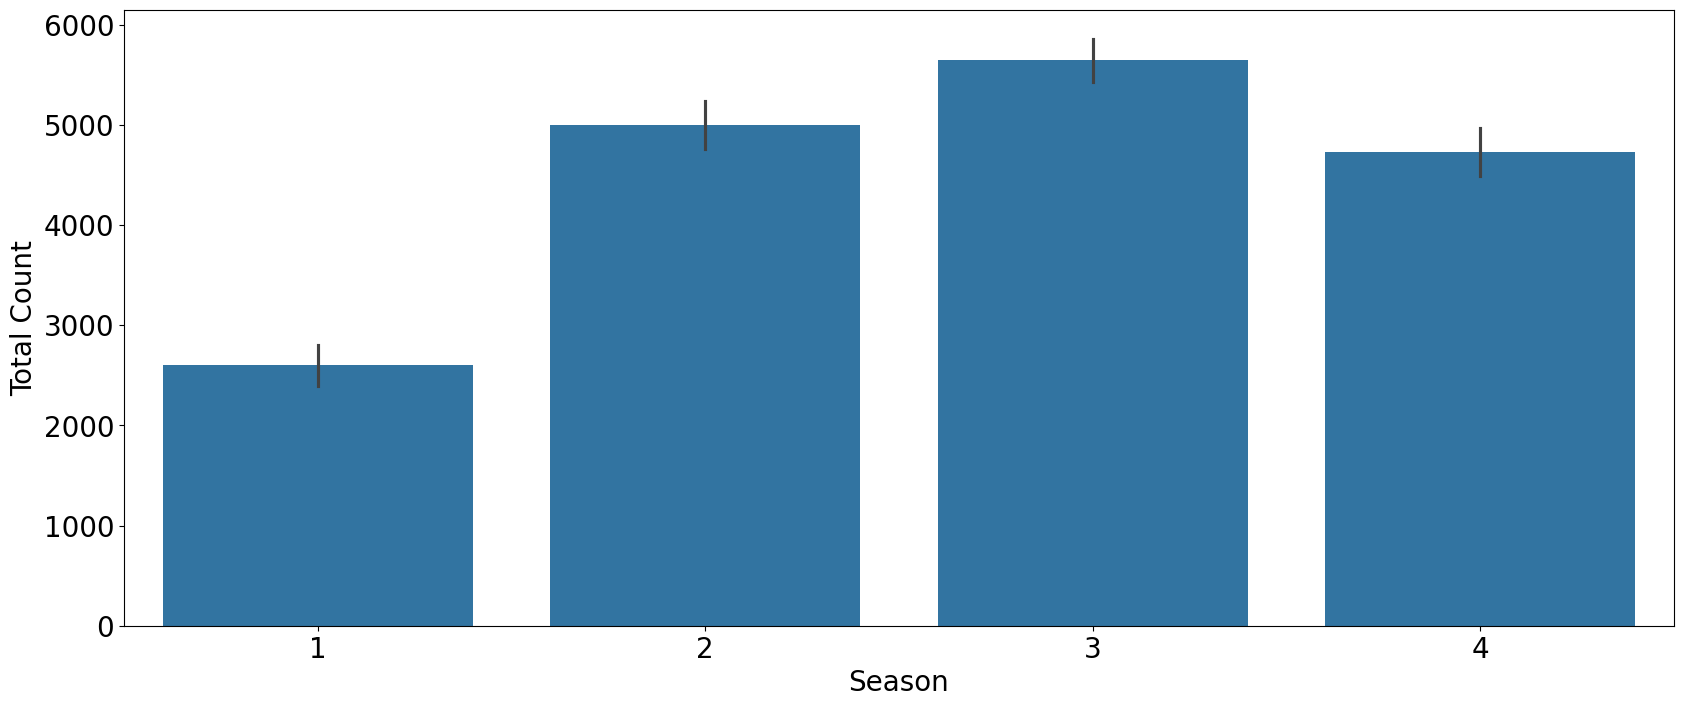

In [35]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'season', y = 'cnt')
plt.xlabel('Season', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
season (1:springer, 2:summer, 3:fall, 4:winter)
- Bike demand is lowest during Spring (Season 1), Demand increases significantly in Summer (Season 2). Highest demand is observed in Fall (Season 3). The demand slightly decreases in Winter (Season 4).
- Bike demand varies across seasons, reflecting seasonal trends in user behavior. Certain seasons(fall) experience higher demand, likely due to favorable weather and outdoor activity preferences.

In [36]:
# Year vs vs Total Count

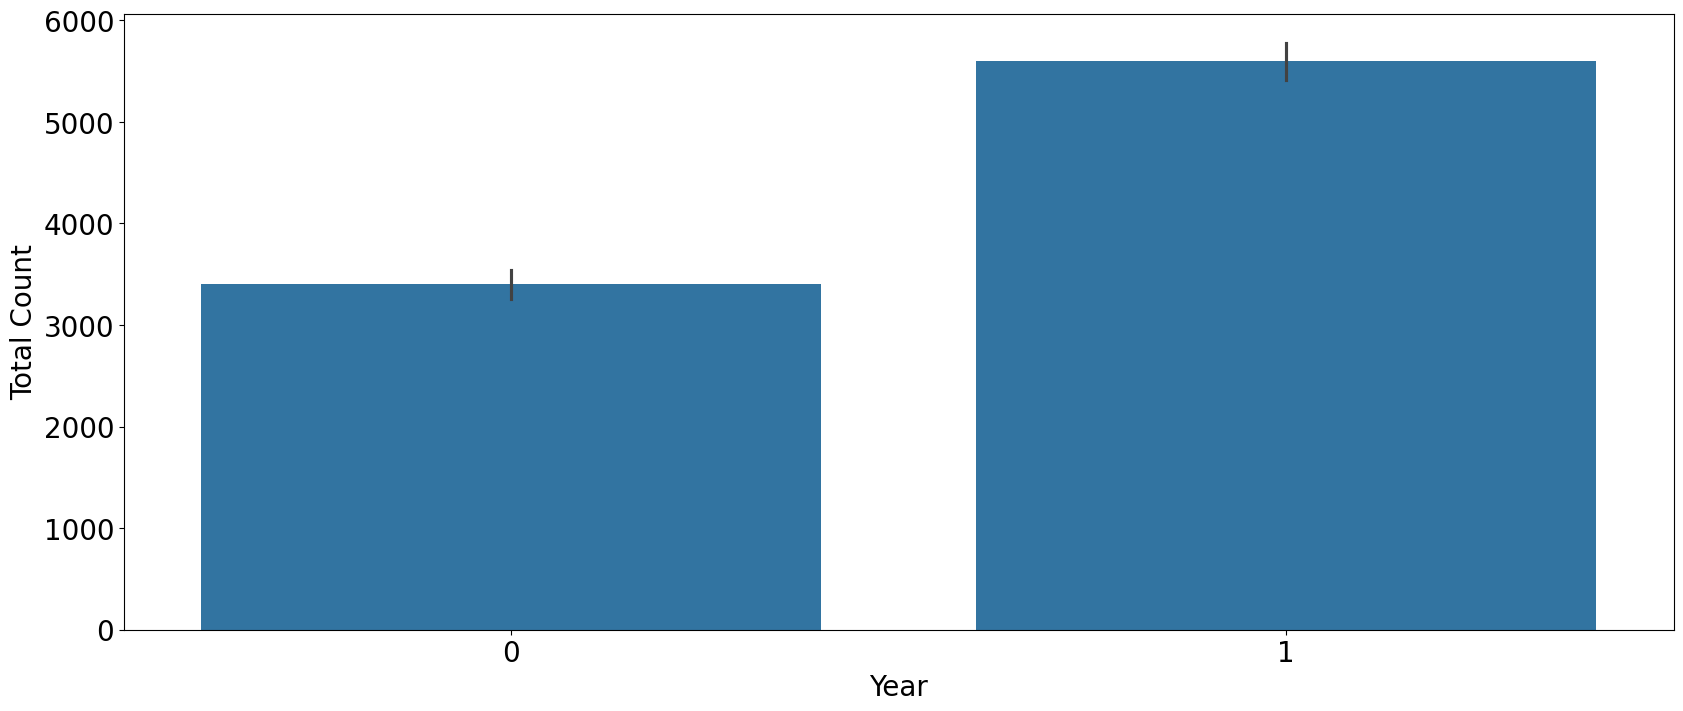

In [37]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'yr', y = 'cnt')
plt.xlabel('Year', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
yr : year (0: 2011, 1:2012)

- The average demand for bikes were higher in year 2012 as compared to year 2011.

In [38]:
# Month vs Total Count

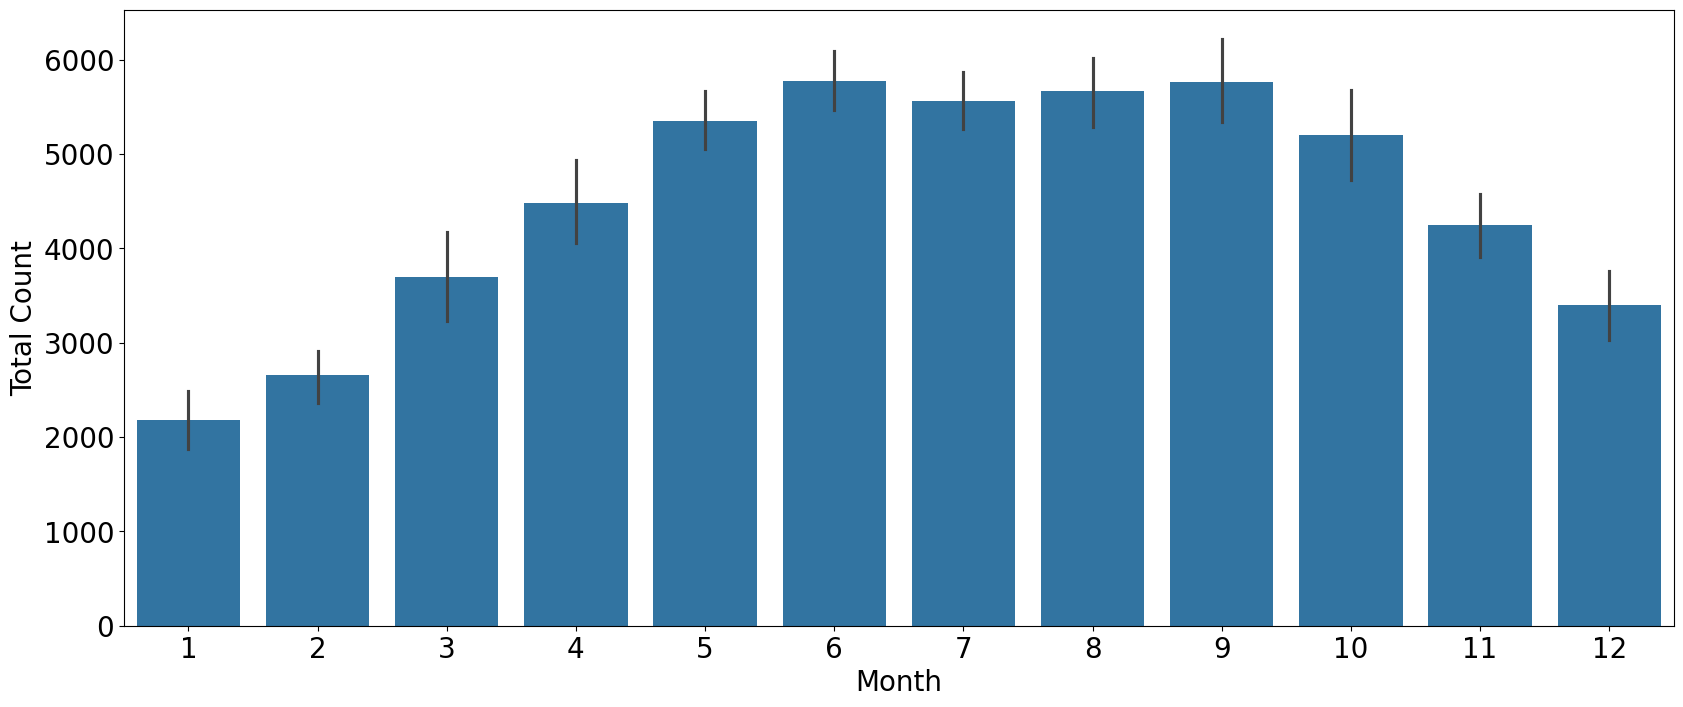

In [39]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'mnth', y = 'cnt')
plt.xlabel('Month', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:

- The average bike demand gradually increases from month 1 to month 6. It stay more or less same till month 9 and then gradually decrease from month 9 to month 12.
- Months influence bike demand. Initials months from month 1 to month 6 tend to have increasing usage, Then from month 6 to month 9 demand stablize and then from month 9 to month 12 demand decreases.

In [40]:
# Holiday vs Total Count

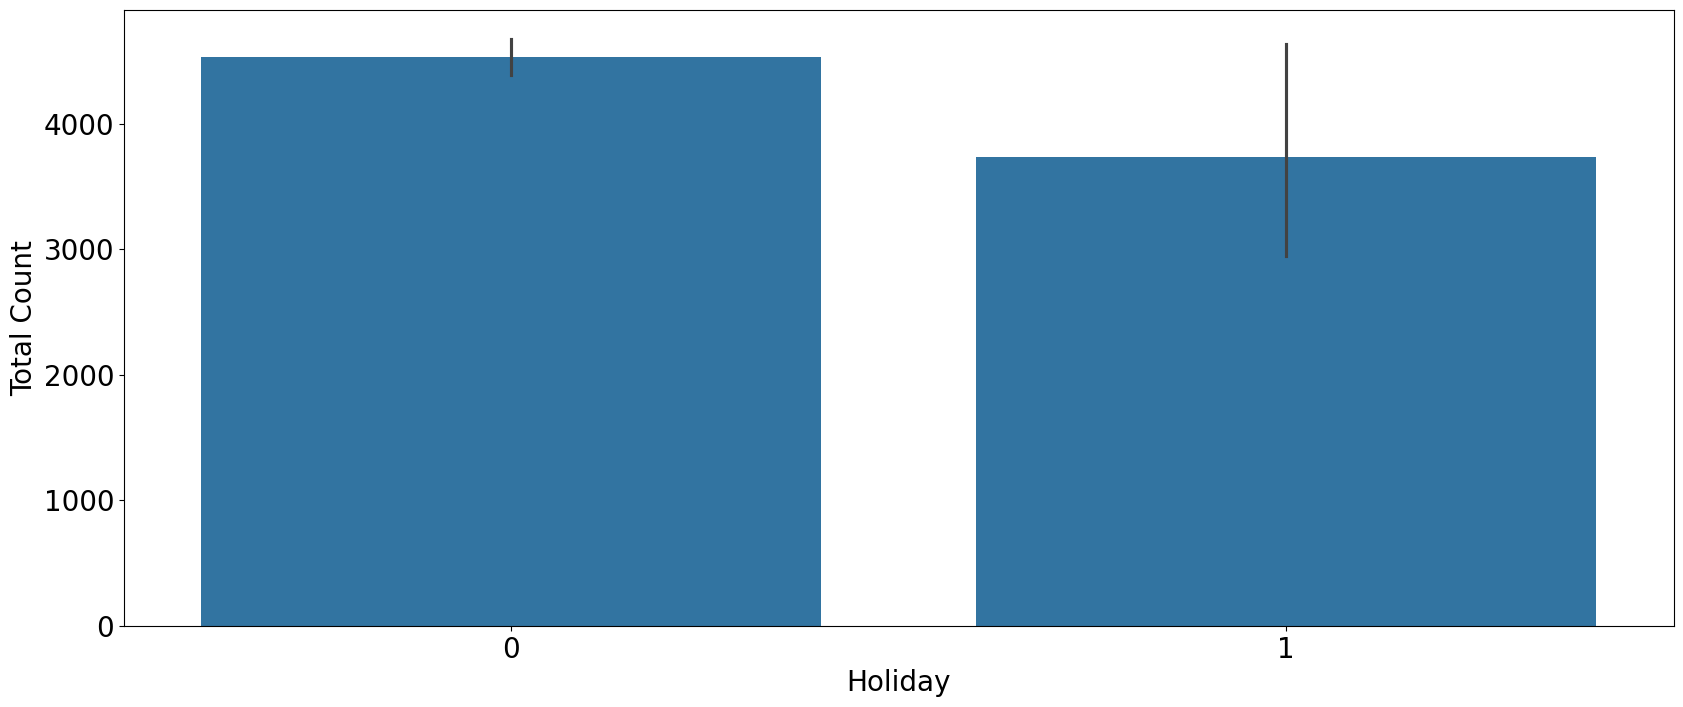

In [41]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'holiday', y = 'cnt')
plt.xlabel('Holiday', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
- The average demand for bikes is higher in when there is no holidays.

In [42]:
# Weekday vs Total Count

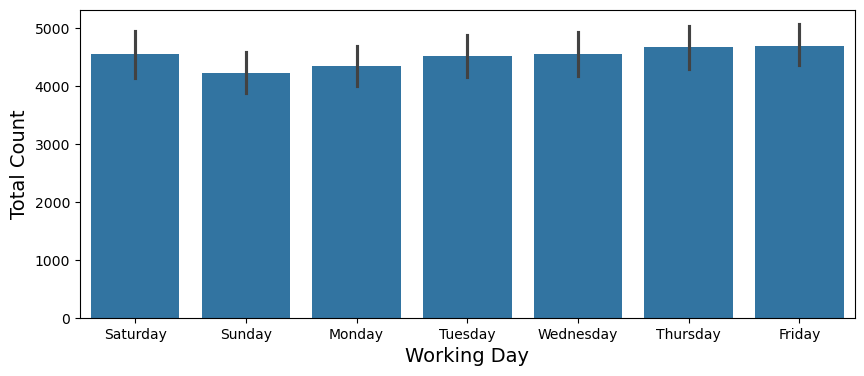

In [43]:
# for the ease of interpration of This plot we will map each number to weekdays Name
df['weekday_name'] = df['weekday'].map({0: 'Sunday', 1: 'Monday', 2 : 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'})

plt.figure(figsize = (10,4))
sns.barplot(data = df, x = 'weekday_name', y = 'cnt')
plt.xlabel('Working Day', fontsize = 14)
plt.ylabel('Total Count', fontsize = 14)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

#### Insights:

- The average demand for bikes is more or less same except for Sunday where the demand is slightly lowers that other working days.

In [44]:
df.drop(['weekday_name'], axis = 1, inplace = True) # The new columns created is dropped.

In [45]:
# Working Day vs Total Count

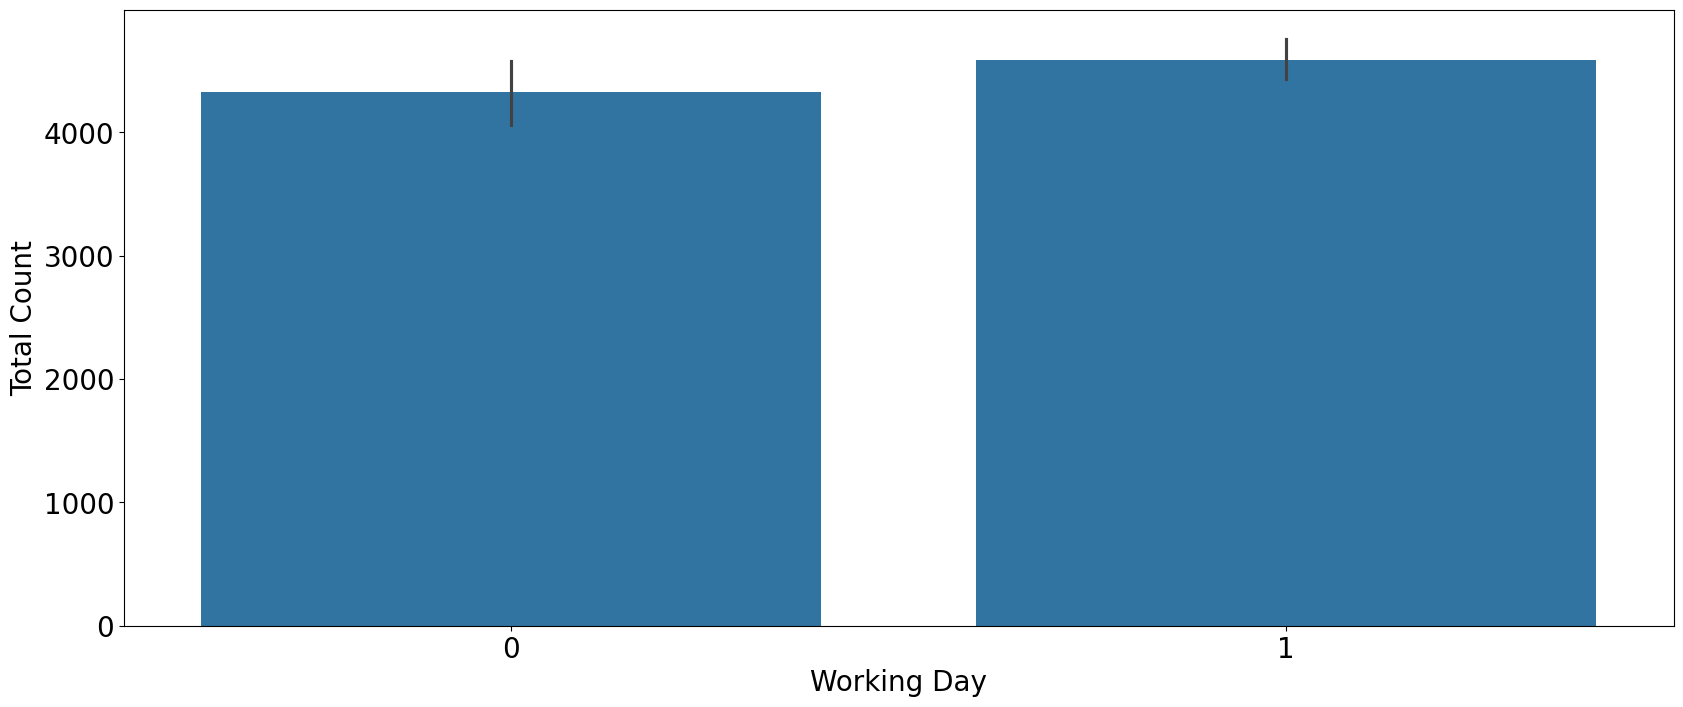

In [46]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'workingday', y = 'cnt')
plt.xlabel('Working Day', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:

- The average demand for bikes is slightly more when neither weekend (nor holiday) as compared to weekend or holidays.

In [47]:
# Weather Situation (weather condition of that day) vs Total Count

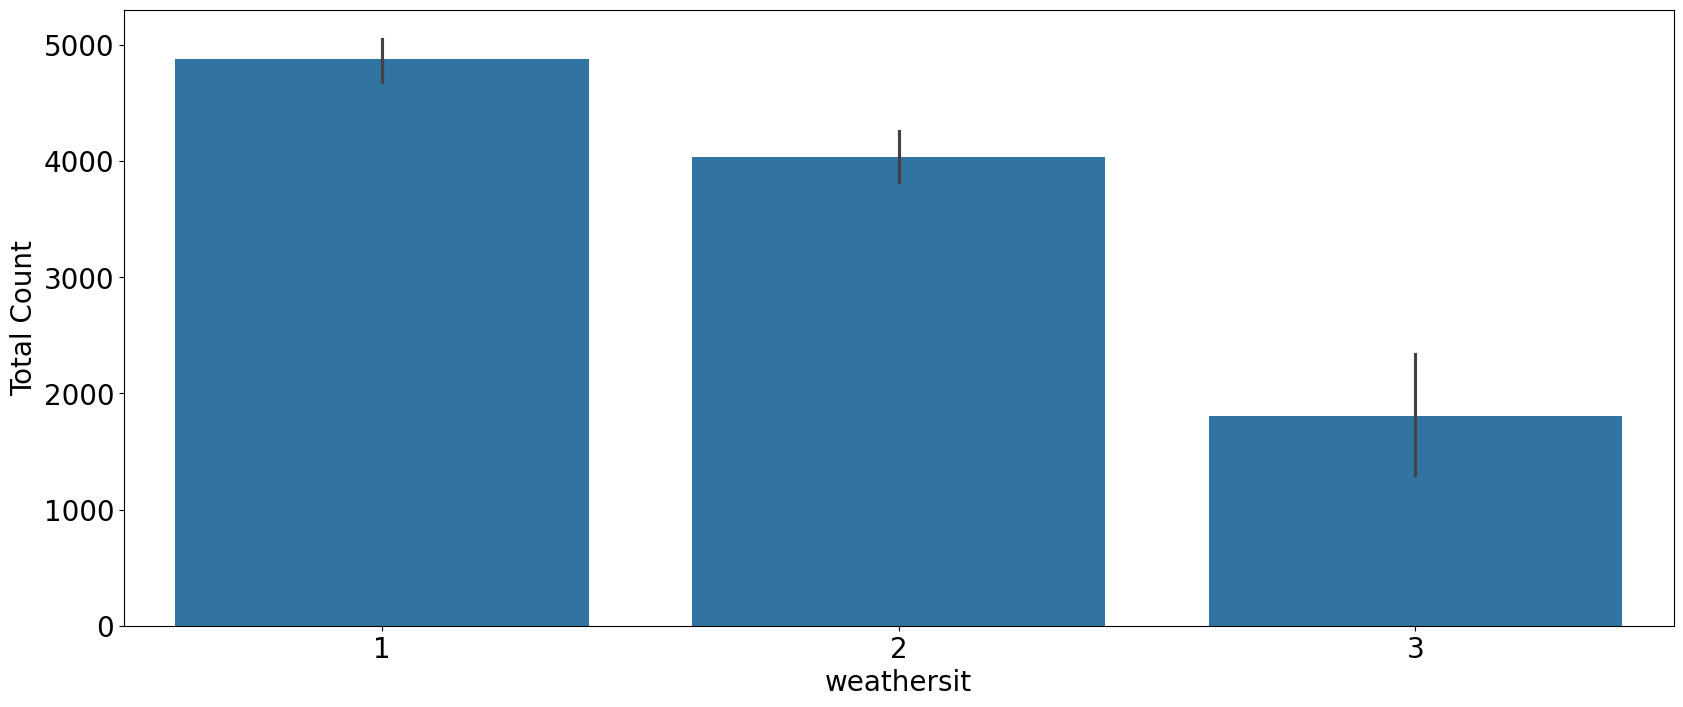

In [48]:
plt.figure(figsize = (20,8))
sns.barplot(data = df, x = 'weathersit', y = 'cnt')
plt.xlabel('weathersit', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
- Bike demand is lowest during when weather situation is 3 (when the weather is having these conditions Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds)
- Bike demand is highest during  weather situation 1 (when the weather is clear, there are few clouds or partly cloudy.
- Bike demand is moderate during  weather situation 2 (Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist).

### Categorical vs Numerical

In [49]:
# Year vs Total Count

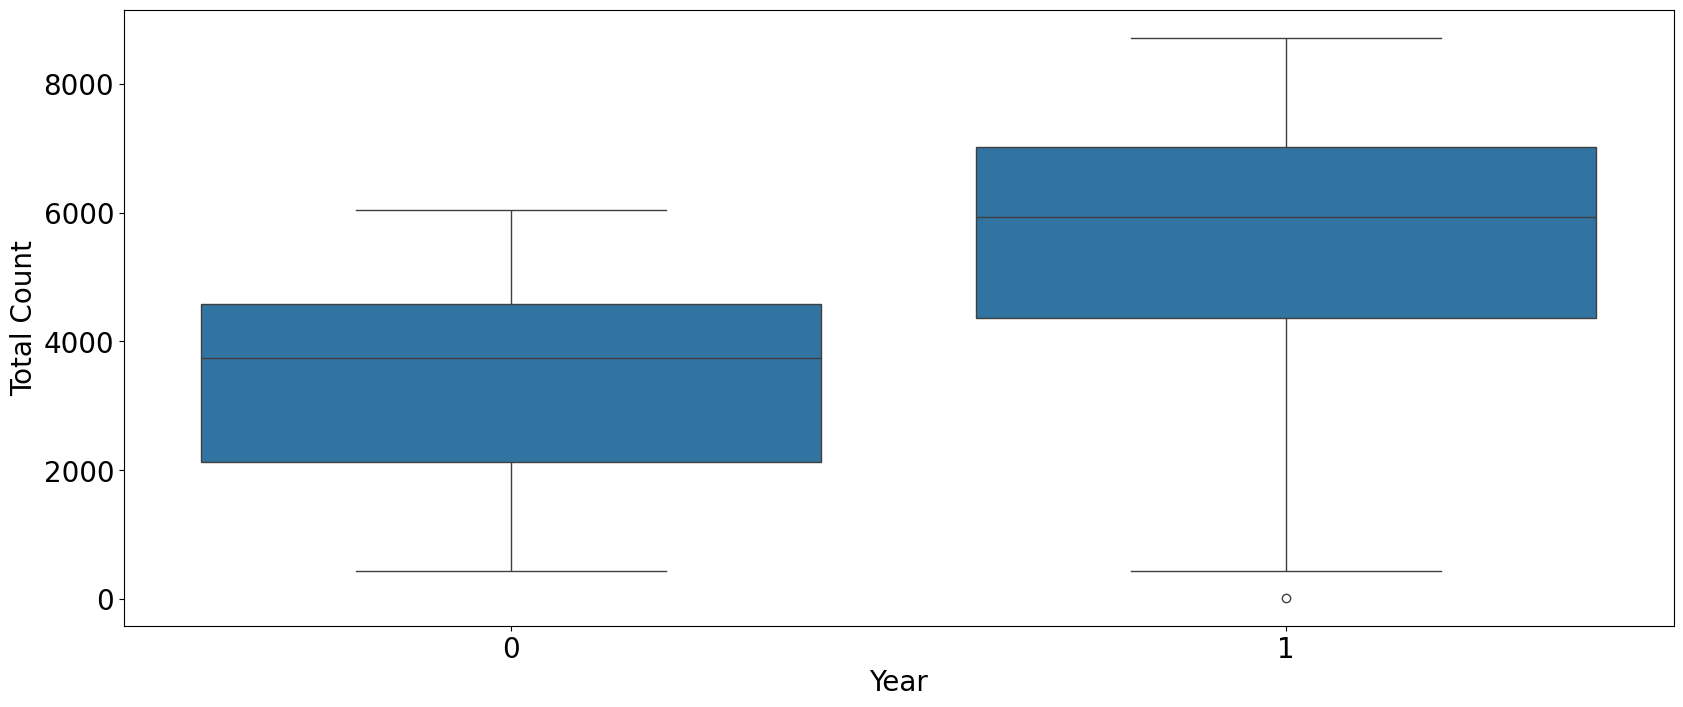

In [50]:
plt.figure(figsize = (20,8))
sns.boxplot(data = df, x = 'yr', y = 'cnt')
plt.xlabel('Year', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
- The median demand for bikes were higher in year 2012 as compared to year 2011.

In [51]:
# Month vs Total Count

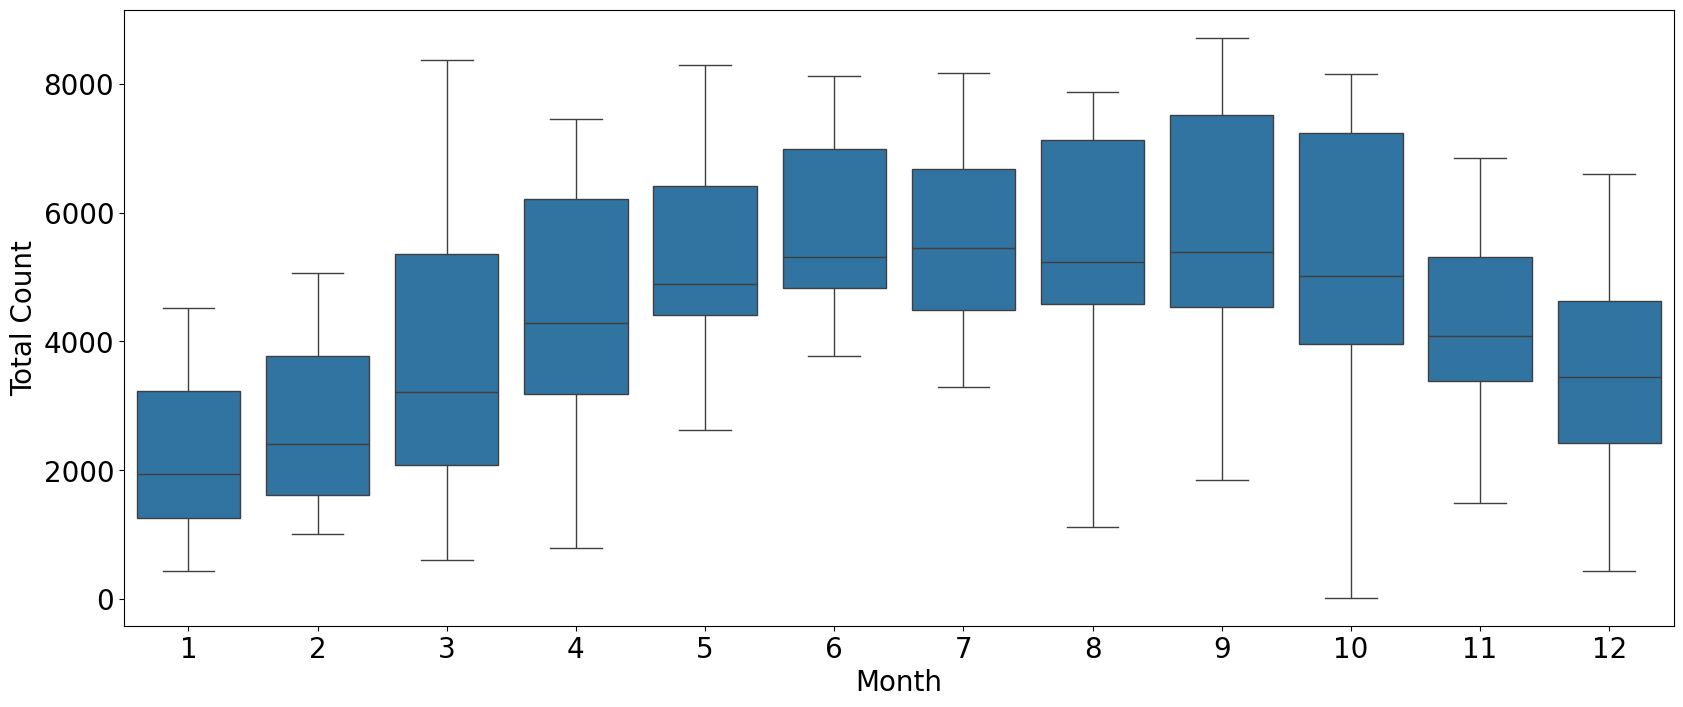

In [52]:
plt.figure(figsize = (20,8))
sns.boxplot(data = df, x = 'mnth', y = 'cnt')
plt.xlabel('Month', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:

- The median bike demand gradually increases from month 1 to month 6. It stay more or less same till month 9 and then gradually decrease from month 9 to month 12.
- Months influence bike demand. Initials months from month 1 to month 6 tend to have increasing usage, Then from month 6 to month 9 demand stabilize and then from month 9 to month 12 demand decreases.

In [53]:
# Holiday vs Total Count

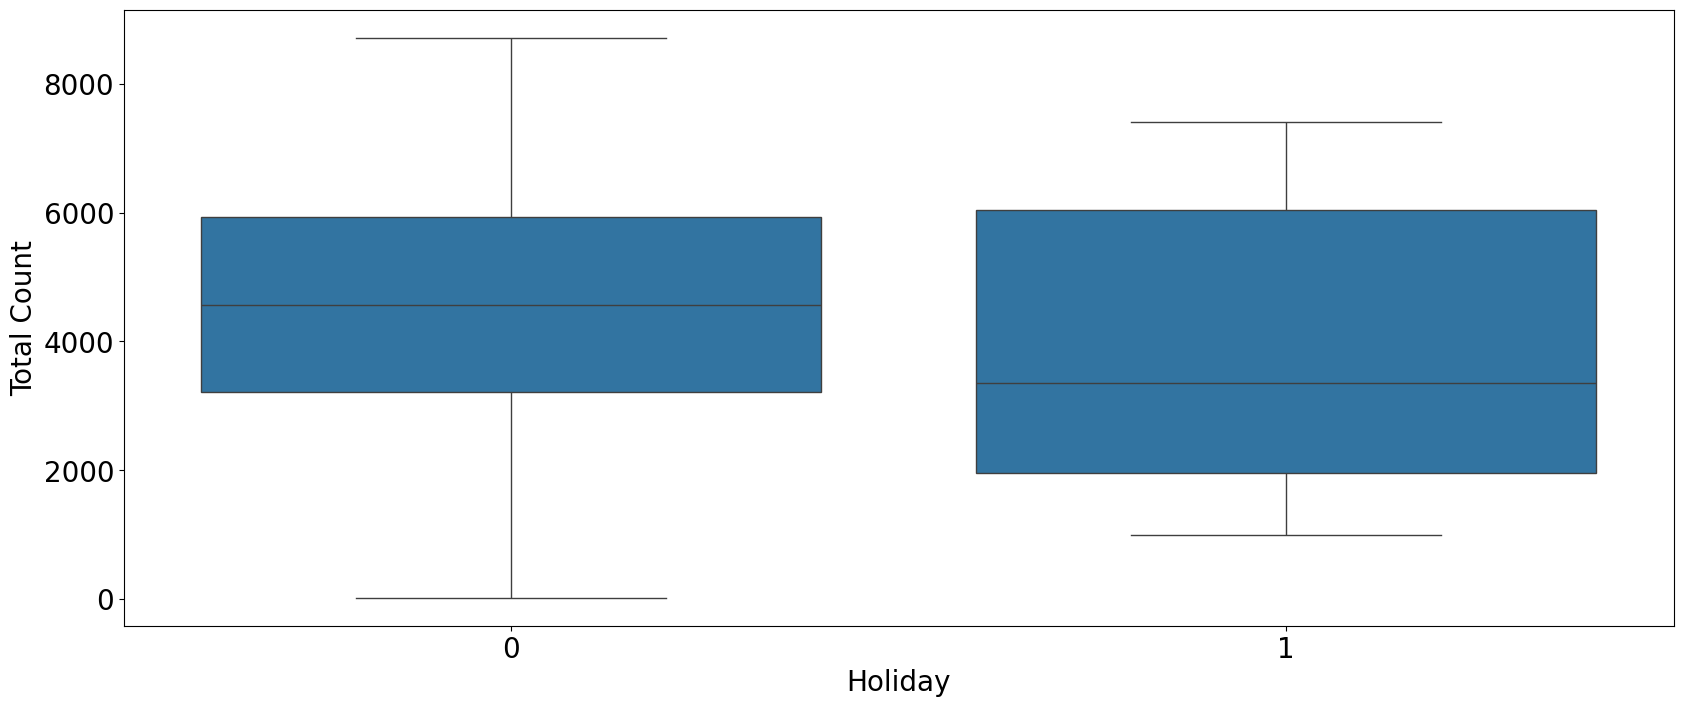

In [54]:
plt.figure(figsize = (20,8))
sns.boxplot(data = df, x = 'holiday', y = 'cnt')
plt.xlabel('Holiday', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:

- The median demand for bikes is higher in when there is no holidays.
- However the IQR is higher when there is holiday.

In [55]:
# Holiday vs Total Count

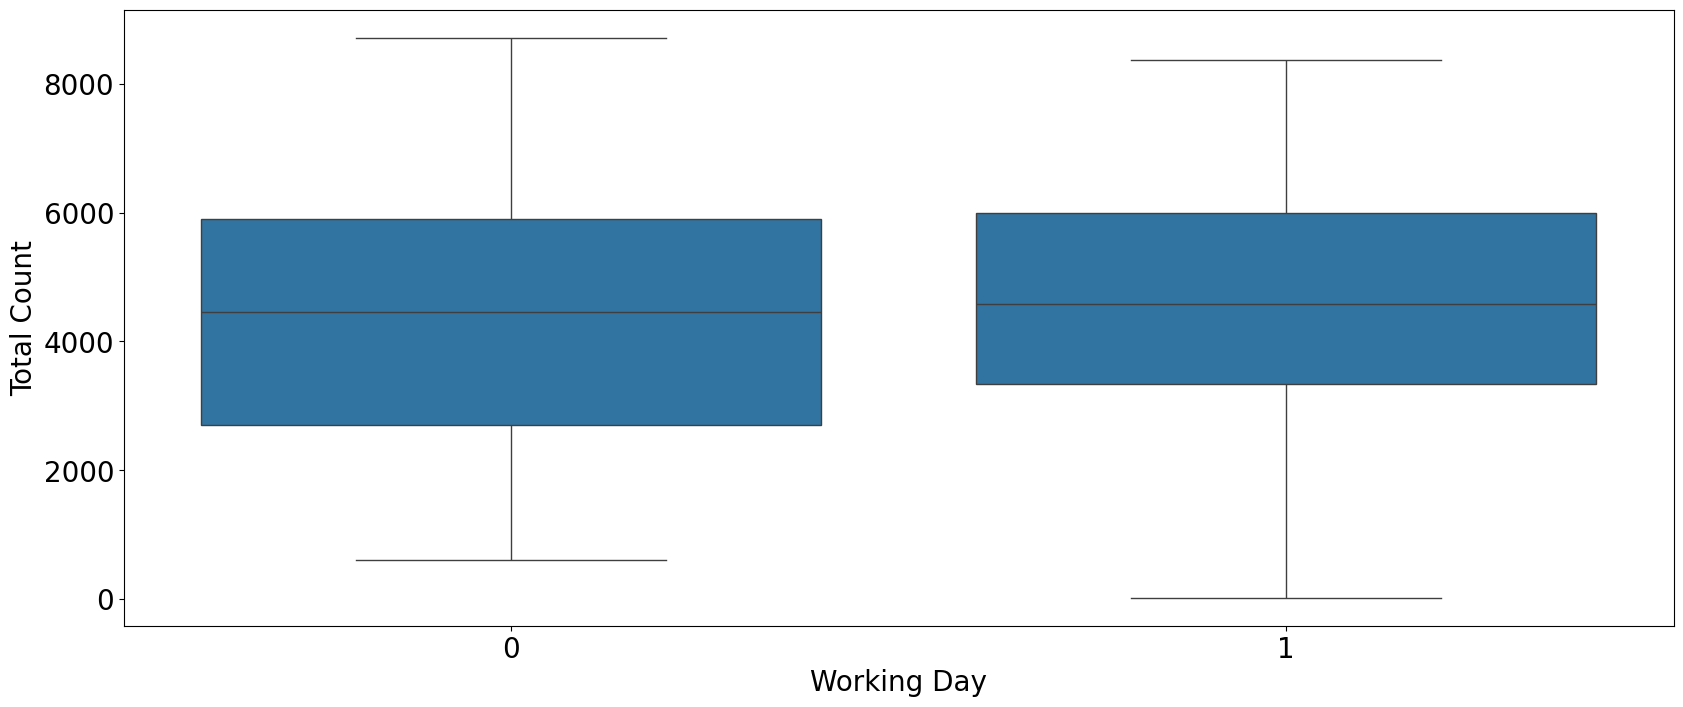

In [56]:
plt.figure(figsize = (20,8))
sns.boxplot(data = df, x = 'workingday', y = 'cnt')
plt.xlabel('Working Day', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:

- The median demand for bikes is slightly more when neither weekend (nor holiday) as compared to weekend or holidays suggesting different usage patterns such as commuting on weekdays and recreational usage on weekends.

In [57]:
# Weather Situation vs Total Count

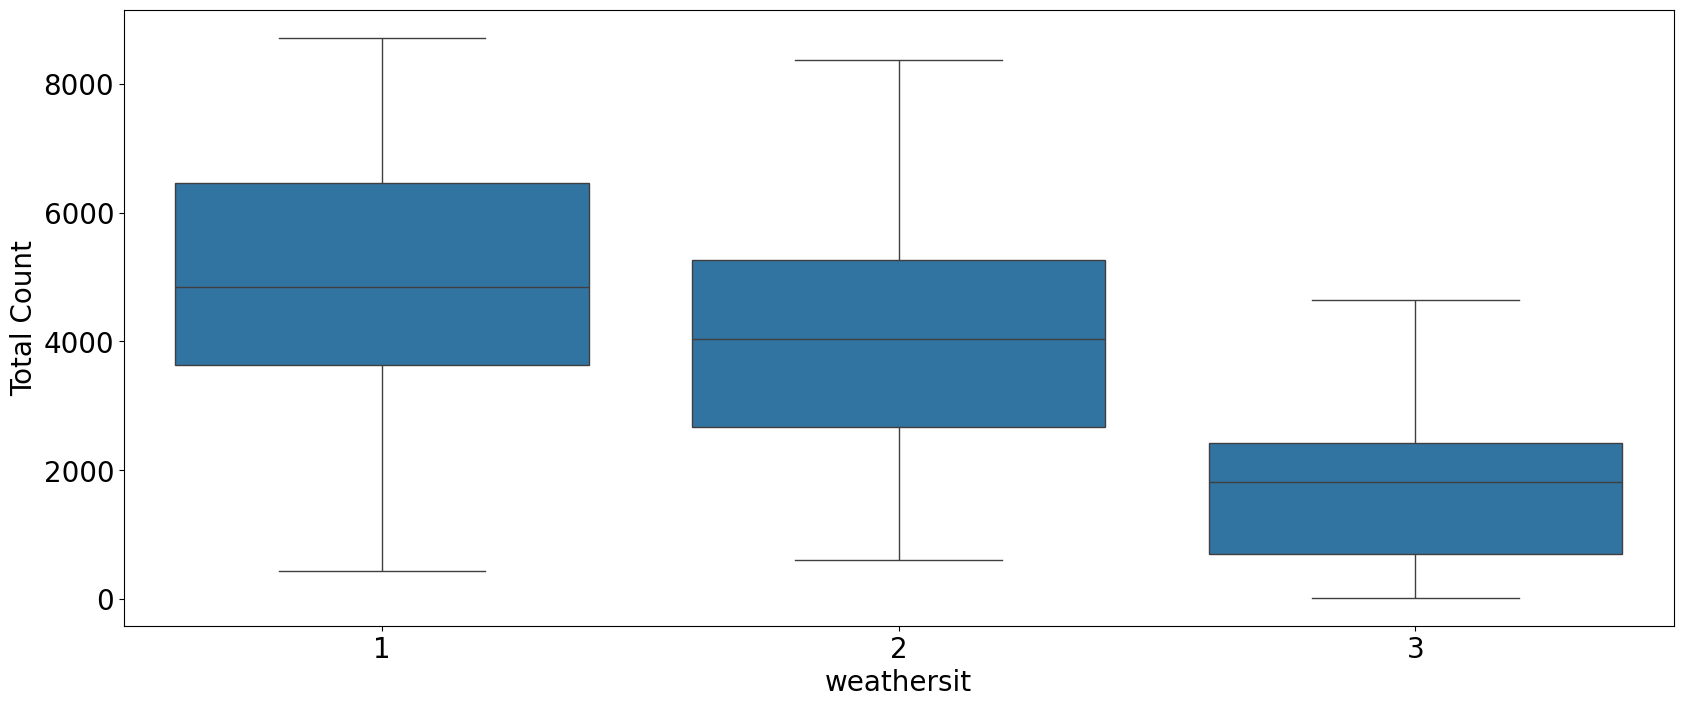

In [58]:
plt.figure(figsize = (20,8))
sns.boxplot(data = df, x = 'weathersit', y = 'cnt')
plt.xlabel('weathersit', fontsize = 20)
plt.ylabel('Total Count', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

#### Insights:
- The median bike demand is lowest during when weather situation is 3. The median bike demand is highest during  weather situation 1. The median bike demand is moderate during  weather situation 2.
- This indicates that the bike demand decreases significantly during poor weather conditions, highlighting the strong negative impact of weather on usage. This indicates that adverse weather discourages outdoor activities like biking.

#### Seasonality effect is strong:
- Highest demand → Fall & Summer
- Lowest → Spring
#### Weather impact:
- Clear weather → highest demand
- Bad weather → lowest demand
#### Working days:
- Slightly higher demand compared to non-working days

# Checking Correlation (Without Target Feature):
### Multicollinearity check

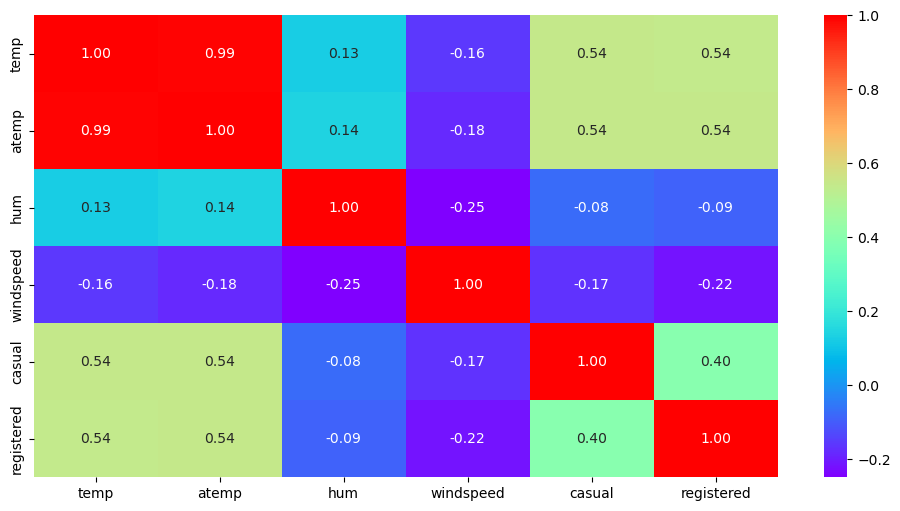

In [59]:
cols = ['temp', 'atemp',  'hum', 'windspeed', 'casual' , 'registered']
plt.figure(figsize = (12,6))
sns.heatmap(df[cols].corr(), fmt='.2f', cmap='rainbow', annot=True, annot_kws={"fontsize": 10})
plt.show()

- High Multicolinearity between temp and atemp
- temp and atemp also show moderate multicollinearity with casual and registered.
- Registered and casual show a moderate multicollinearity.

# Checking Correlation (Independent + Target):

### Understanding predictive strength
### Choosing variables that are meaningful to cnt prediction

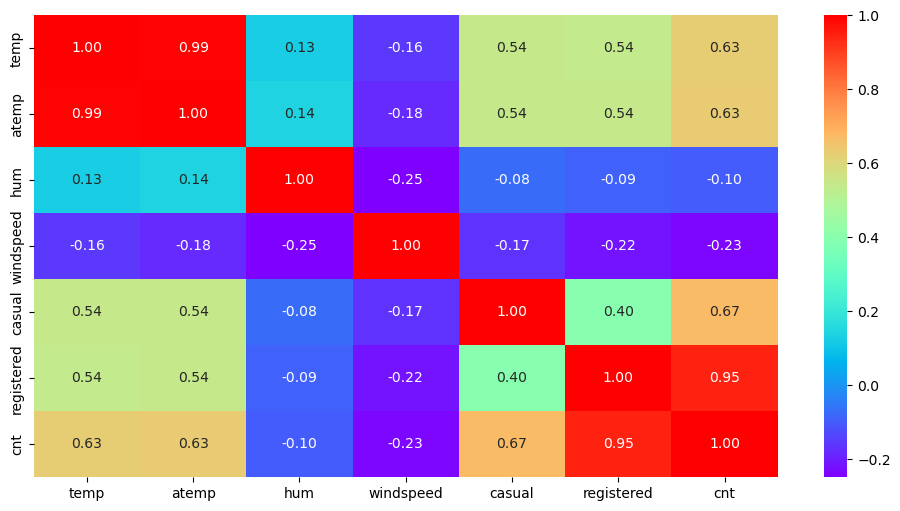

In [60]:
cols = ['temp', 'atemp',  'hum', 'windspeed', 'casual' , 'registered', 'cnt']
plt.figure(figsize = (12,6))
sns.heatmap(df[cols].corr(), fmt='.2f', cmap='rainbow', annot=True, annot_kws={"fontsize": 10})
plt.show()

#### Insights:
- registered have a strong positive correlation with cnt.
- casual, temp, atemp also show a moderate positive correlation with cnt.

# EDA Insights:

- **Temperature** has a positive relationship with bike demand — higher temperature leads to more bike rentals.
This means bike demand increases with temperature, indicating higher usage during warmer conditions. This suggests that people prefer biking in comfortable weather, making temperature a key driver of demand.
- **Weather conditions** significantly impact demand — bad weather reduces bike usage.
- **Working days vs non-working days** show different usage patterns, indicating behavioral trends.
- **Seasonality** plays an important role in demand variation. Bike demand decreases significantly during poor weather conditions, highlighting the strong negative impact of weather on usage. This indicates that adverse weather discourages outdoor activities like biking.

# Outliers Treatment?

- Humidity shows some low-value observations, but since the data is normalized, these are valid and do not require treatment.

# Step 5: Data Processing

### 1. Removing Unwanted Features

In [61]:
# Reomve Features that are not relevant for model (instant, dteday, casual, casual, atemp)
df.drop(['instant', 'dteday', 'casual','registered'], axis = 1, inplace = True)

In [62]:
df.shape

(731, 12)

### Feature Removal

#### 1. instant
- This is just a unique identifier for each record
- It does not carry any meaningful information for prediction


#### 2. dteday
- This represents the exact date
- Instead of using raw date, we already have extracted useful features such as:
  - yr (year)
  - mnth (month)
  - weekday
- Therefore, this column is redundant and removed

#### 3. casual and registered
- These represent the number of casual and registered users
- The target variable cnt is the sum of these two:
  
  cnt = casual + registered

- Including them would lead to **data leakage**, as they directly determine the target variable
- Hence, they were removed to ensure a realistic and generalizable model

### 2. Calculate VIF & Remove multicollinearity 

- We Why not include casual and registered in VIF
- Although they can be used during EDA, they are components of the target variable and not true predictors. Including them in VIF can distort multicollinearity analysis, so they should be excluded before feature selection.

In [63]:
X = df[['temp','atemp', 'hum', 'windspeed']]

Y = df[['cnt']]

In [64]:
X.head()

,temp,atemp,hum,windspeed
0,0.344167,0.363625,0.805833,0.160446
1,0.363478,0.353739,0.696087,0.248539
2,0.196364,0.189405,0.437273,0.248309
3,0.200000,0.212122,0.590435,0.160296
4,0.226957,0.229270,0.436957,0.186900


In [65]:
X = sm.add_constant(X)

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Feature,VIF
0,const,45.633543
1,temp,62.969819
2,atemp,63.632351
3,hum,1.079267
4,windspeed,1.126768


- atemp (feels-like temperature) is highly correlated with temp. This causes multicollinearity (high VIF)
- To improve model stability and interpretability, atemp was removed. This selection ensures low multicollinearity, interpretability of coefficients.

In [67]:
df.drop('atemp', axis = 1, inplace = True)
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


In [68]:
df.shape

(731, 11)

- The columns are reduced from 16 to 11.

## Final Insights

- Bike demand is strongly influenced by seasonality and weather conditions
- Temperature has a positive impact on demand
- Humidity has a negative impact on demand
- Working days show slightly higher demand than non-working days
- The dataset does not contain missing values or inconsistencies
- Multicollinearity was handled by removing highly correlated features (`atemp`)
- Data leakage was prevented by removing `casual` and `registered`

## EDA to Feature Selection

### Insights: 

Based on the exploratory data analysis, several important patterns were identified:

- Temperature showed a strong positive relationship with bike demand.
- Weather conditions had a significant negative impact.
- Seasonal and monthly trends indicated clear variations in demand.
- Working days and holidays reflected different usage patterns.

In addition to these insights, feature selection was performed to improve model performance:

- Irrelevant and redundant features were removed.
- Multicollinearity was addressed using VIF (Variance Inflation Factor), ensuring that only meaningful and independent features were retained.

The final features used for modeling are:

- season  
- yr  
- mnth  
- holiday  
- weekday  
- workingday  
- weathersit  
- temp  
- hum  
- windspeed  

These steps ensure that the model is built using relevant, non-redundant, and data-driven features.

### 5. Train-Test Split

In [69]:
# Separate features and target
X = df.drop('cnt', axis=1)
Y = df['cnt']

In [70]:
X.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900


In [71]:
X.shape

(731, 10)

In [72]:
Y.head()

0     985
1     801
2    1349
3    1562
4    1600
Name: cnt, dtype: int64

In [73]:
Y.shape

(731,)

- X have all the independent features
- Y have the traget feature

In [74]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print('X_train Shape: ', X_train.shape) # Shape of X_train
print('y_train Shape: ', y_train.shape) # Shape of y_train
print('X_test Shape: ', X_test.shape)# Shape of X_test
print('y_test Shape: ', y_test.shape)# Shape of y_test

X_train Shape:  (584, 10)
y_train Shape:  (584,)
X_test Shape:  (147, 10)
y_test Shape:  (147,)


In [75]:
# Check the split size

X_train.shape[0]/df.shape[0]* 100

79.89056087551299

In [76]:
X_test.shape[0]/df.shape[0]* 100

20.109439124487004

In [77]:
y_train.shape[0]/df.shape[0]* 100

79.89056087551299

In [78]:
y_test.shape[0]/df.shape[0]* 100

20.109439124487004

- The train and test size is exactly same.

In [79]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


## Scaling & Encoding:

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ['season', 'mnth', 'weekday', 'weathersit']
numerical_features = ['temp', 'hum', 'windspeed']
binary_features = ['yr', 'holiday', 'workingday']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),   # Scaling within pipeline
        ('bin', 'passthrough', binary_features)
    ]
)

In [81]:
preprocessor

,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [82]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [83]:
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', LinearRegression())])

In [84]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Insight:

Linear Regression model used due to:
- Linear relationships observed in EDA
- Simplicity and interpretability

Model trained using a Pipeline, ensuring:
- Clean workflow
- Reusable transformations

In [85]:
# Prediction

In [86]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# STEP 6: Model Evaluation

In [87]:
from sklearn.metrics import r2_score, mean_squared_error

In [88]:
print('Train_R2-Score: ', r2_score(y_train, y_train_pred))
print('Test_R2-Score: ', r2_score(y_test, y_test_pred))

Train_R2-Score:  0.8466777704312574
Test_R2-Score:  0.8410745782487739


In [89]:
print('Train_MSE: ', mean_squared_error(y_train, y_train_pred))
print('Test_MSE: ', mean_squared_error(y_test, y_test_pred))

Train_MSE:  562033.534451114
Test_MSE:  637272.233885898


In [90]:
print('Train_RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test_RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train_RMSE: 749.6889584695202
Test_RMSE: 798.2933257179957


#### Insights:

- R² Score indicates how well the model explains variance in the data.
- RMSE (Root Mean Squared Error) measures prediction error. The typical prediction error is around 800 bikes. It means that on average, the model’s predictions are off by around 800 bikes compared to actual demand. Given that the maximum demand in the dataset is around 8700 bikes, this corresponds to roughly a 9–10% prediction error, which is reasonable for a baseline model.

A higher R² and lower RMSE indicate better model performance. This gives us a baseline to compare with future models.

The model demonstrates strong performance with consistent results across both training and testing datasets.

- The **R² score** is approximately 0.84 for both train and test sets, indicating that the model explains around 84% of the variance in bike demand.
- The close values of train and test R² suggest that the model generalizes well and is not overfitting.

- The **RMSE values** for train (749) and test (798) are relatively close, further confirming that the model performs consistently on unseen data.

- The slightly higher RMSE on the test set is expected and indicates normal generalization behavior.

Overall, the model provides a reliable baseline for predicting bike demand and captures the key patterns in the data effectively.


- MSE is included for completeness but is less interpretable due to squared units.
- RMSE is preferred as it provides error in the same unit as the target variable.

In [91]:
# STEP 2: 

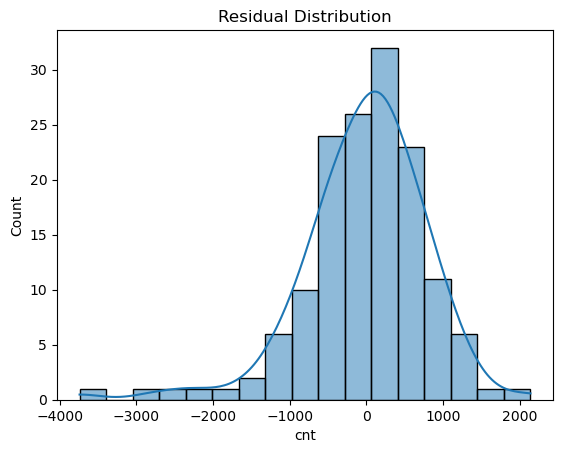

In [92]:
residuals = y_test - y_test_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

#### Insights:

- 1. Centered Around Zero: Model is not overpredicting or underpredicting.This indicates that the model does not have significant bias and predictions are balanced.
- 2. Roughly Normal Distribution: Errors are random (good sign). - The random spread of residuals suggests that the model has captured the underlying patterns in the data effectively.
- 3. Some Extreme Values: Model makes large errors in some cases. Normal in real data.- Some extreme residual values are present, indicating occasional large prediction errors, which is expected in real-world data.

Overall, the residual analysis confirms that the model assumptions are reasonably satisfied and the model performs reliably.

# Step 7: Feature Importance

In [93]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipeline.named_steps['model'].coef_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
25,bin__yr,1980.059449,1980.059449
21,cat__weathersit_3,-1839.482803,1839.482803
2,cat__season_4,1654.881427,1654.881427
0,cat__season_2,955.968013,955.968013
22,num__temp,886.312387,886.312387
10,cat__mnth_9,837.030972,837.030972
1,cat__season_3,816.518784,816.518784
4,cat__mnth_3,581.214682,581.214682
6,cat__mnth_5,532.633790,532.633790
20,cat__weathersit_2,-509.251281,509.251281


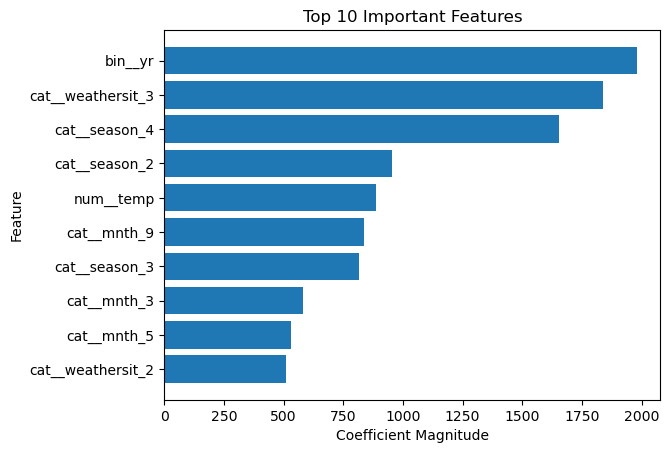

In [94]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Abs_Coefficient'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.show()

### Feature Importance Interpretation

The feature importance analysis highlights the key drivers of bike demand:

- **Year (yr)** has the strongest influence, indicating a significant increase in demand over time.
- **Weather conditions (especially severe weather)** negatively impact bike usage.
- **Seasonal features** show that demand varies across different times of the year.
- **Temperature** has a positive effect, confirming that higher temperatures lead to increased bike rentals.

These findings strongly align with the insights observed during exploratory data analysis, validating the model's behavior.

## Model Interpretation and EDA Alignment

The feature importance results align well with the patterns observed during EDA:

- Temperature and weather-related features show strong influence on predictions.
- Seasonal variables contribute significantly, reflecting demand variation across time.
- Temporal features like year also capture growth trends in bike usage.

This consistency between EDA findings and model behavior validates that the model has successfully learned the underlying patterns in the data.

# Step 8: Save Model

In [95]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

#### Insight:
- Model saved using pickle
- It allows: Reuse without retraining & Deployment in real applications

# Step 9: Inference

In [96]:
def predict(data):
    return pipeline.predict(data)

#### Insight:
Created a prediction function for new data
This enables: Real-time predictions & Integration with applications

# Step 9: Final Conclusion

- Built an end-to-end bike demand prediction model
- Identified key factors affecting demand:
  - Temperature
  - Weather conditions
  - Seasonality
- Developed a **Linear Regression baseline model**
- Evaluated model using R² and RMSE
- Data leakage was prevented by removing target-derived features
- Multicollinearity was handled using VIF analysis
- A robust machine learning pipeline was built using scikit-learn
- The model demonstrates good predictive performance and is ready for deployment

## Next Steps:

- Deploy model using FastAPI
- Build interactive UI using Streamlit
- Convert notebook pipeline into production-ready code

#### This project demonstrates the complete ML workflow from data analysis to model building.

### Future Improvements (not part of this project):

- To Try advanced models like Random Forest or XGBoost
- Perform hyperparameter tuning
- Improve feature engineering

In [97]:
# End